# 🧫 Pipeline v3 — Detecção de Colônias (Lab + K-Means + blob_log)
```
Imagem → ROI → Lab(L,b) → CLAHE → K-Means k=4 → blob_log → Filtros forma → Contagem
```
**Mudanças vs v2:** sem Top-Hat, sem Otsu global; K-Means só nos pixels da placa;
espaço Lab(L,b) em vez de V puro; blob_log como alternativa; filtros de circularidade + solidez.

In [ ]:
# ── Setup ──────────────────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os, json, glob, warnings
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import measure, color, feature
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

# --- Function Definitions (Consolidated) ---
def mostrar(imgs, titulos, figsize=(18, 5)):
    fig, axes = plt.subplots(1, len(imgs), figsize=figsize)
    if len(imgs) == 1: axes = [axes]
    for ax, img, t in zip(axes, imgs, titulos):
        ax.imshow(img, cmap='gray' if img.ndim == 2 else None)
        ax.set_title(t); ax.axis('off')
    plt.tight_layout(); plt.show()

def detectar_placa(img_rgb, param1=50, param2=30, margem=10):
    cinza = cv2.GaussianBlur(cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY), (9,9), 2)
    h, w = cinza.shape
    circulos = cv2.HoughCircles(cinza, cv2.HOUGH_GRADIENT, 1.2,
                                 int(min(h,w)*0.5), param1=param1, param2=param2,
                                 minRadius=int(min(h,w)*0.3),
                                 maxRadius=int(min(h,w)*0.6))
    if circulos is None:
        print('⚠️ Placa não detectada, usando imagem completa')
        mask = np.ones((h, w), np.uint8) * 255
        return img_rgb, mask, (w//2, h//2, min(h,w)//2)
    cx, cy, r = np.round(circulos[0][0]).astype(int)
    r = min(r + margem, min(h,w)//2)
    mask = np.zeros(cinza.shape, np.uint8)
    cv2.circle(mask, (cx,cy), r, 255, -1)
    # ⚠️ Exclui anel externo (~8% do raio) onde costuma ficar o texto impresso
    r_inner = int(r * 0.92)
    mask_inner = np.zeros_like(mask)
    cv2.circle(mask_inner, (cx,cy), r_inner, 255, -1)
    masked = img_rgb.copy(); masked[mask_inner==0] = 0
    x1,y1 = max(cx-r,0), max(cy-r,0)
    x2,y2 = min(cx+r,w), min(cy+r,h)
    return masked[y1:y2, x1:x2], mask_inner[y1:y2, x1:x2], (cx, cy, r)

def watershed(binaria, img_rgb, dist_thresh=0.5):
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
    sure_bg  = cv2.dilate(binaria, k, iterations=3)
    dist     = cv2.distanceTransform(binaria, cv2.DIST_L2, 5)
    _, sure_fg = cv2.threshold(dist, dist_thresh * dist.max(), 255, 0)
    sure_fg  = np.uint8(sure_fg)
    unknown  = cv2.subtract(sure_bg, sure_fg)
    _, markers = cv2.connectedComponents(sure_fg)
    markers += 1; markers[unknown==255] = 0
    result = img_rgb.copy()
    cv2.watershed(result, markers)
    result[markers==-1] = [255,0,0]
    return result, dist

# Original zip file loading and extraction commented out
# ZIP_PATH = '/content/drive/MyDrive/dataset-20260512T153045Z-3-001.zip'
# extract_dir = os.path.join(os.path.dirname(ZIP_PATH),
#                            os.path.splitext(os.path.basename(ZIP_PATH))[0])
# if not os.path.exists(extract_dir):
#     with zipfile.ZipFile(ZIP_PATH, 'r') as z:
#         z.extractall(extract_dir)
# PASTA = os.path.join(extract_dir, 'dataset')
# print('Dataset em:', PASTA)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 🚀 Setup e Funções Auxiliares

Nesta seção, realizamos a configuração inicial do ambiente e definimos funções auxiliares essenciais para o processamento de imagens. Isso inclui:

*   **Montagem do Google Drive**: Para acesso aos arquivos de dados.
*   **Importação de bibliotecas**: `numpy`, `cv2` (OpenCV), `matplotlib`, `skimage`, `sklearn` para manipulação de imagens, visualização e aprendizado de máquina.
*   **`mostrar`**: Uma função utilitária para exibir múltiplas imagens lado a lado, facilitando a visualização dos resultados intermediários.
*   **`detectar_placa`**: Utiliza a Transformada de Hough para identificar o círculo que representa a placa de Petri na imagem, retornando a região de interesse (ROI) e uma máscara.
*   **`watershed`**: Implementa o algoritmo Watershed para segmentação de objetos, ajudando a separar colônias que estão aglomeradas.

In [ ]:
pip install pillow_heif

HEIC image loaded successfully.


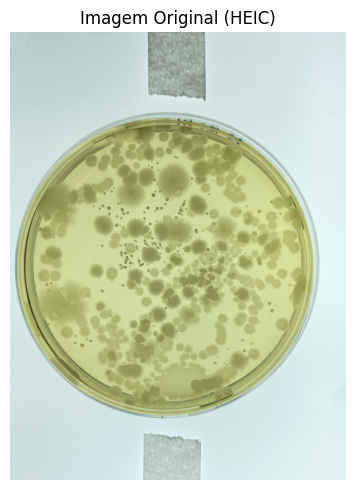

In [ ]:
import pillow_heif
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import measure, color, feature
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

# Load the HEIC image
HEIC_IMAGE_PATH = '/content/drive/MyDrive/IMG_0543.HEIC'
heif_file = pillow_heif.read_heif(HEIC_IMAGE_PATH)
img_orig = np.array(heif_file.to_pillow())

contagem_real = 0 # Placeholder for real count, as it's not available for this single image

print('HEIC image loaded successfully.')
# The 'mostrar' function is now defined in the setup cell (-nH7B6_T2rD2).
mostrar([img_orig], ['Imagem Original (HEIC)'])

## 🖼️ Carregamento da Imagem HEIC

Esta etapa é dedicada ao carregamento da imagem de entrada. Utilizamos a biblioteca `pillow_heif` para lidar com arquivos no formato HEIC, que é comum em dispositivos Apple. A imagem é convertida para um array NumPy e exibida para verificação.

In [ ]:
# ── Utilitários ────────────────────────────────────────────────────────────
# 'mostrar' function definition moved to cell -nH7B6_T2rD2

# Function to load dataset samples (not used for single HEIC image)
def carregar_amostra(pasta, n=10):
    json_map = {os.path.splitext(os.path.basename(p))[0]: p
                for p in glob.glob(os.path.join(pasta, '*.json'))}
    amostras = []
    for p in sorted(glob.glob(os.path.join(pasta, '*.jpg'))):
        if len(amostras) >= n: break
        nome = os.path.splitext(os.path.basename(p))[0]
        if nome not in json_map: continue
        with open(json_map[nome]) as f: dados = json.load(f)
        cnt = dados.get('colonies_number', 0)
        if cnt == 0: continue
        img = cv2.cvtColor(cv2.imread(p), cv2.COLOR_BGR2RGB)
        amostras.append({'nome': nome, 'imagem': img, 'contagem_real': cnt})
    print(f'✅ {len(amostras)} imagens carregadas')
    return amostras

# Original dataset loading and variable assignments are commented out/removed
# as we are now processing a single HEIC image.
# amostras = carregar_amostra(PASTA, n=10)
# img_orig = amostras[0]['imagem']
# contagem_real = amostras[0]['contagem_real']
# print('Colônias reais:', contagem_real)
# mostrar([img_orig], ['Imagem Original'])

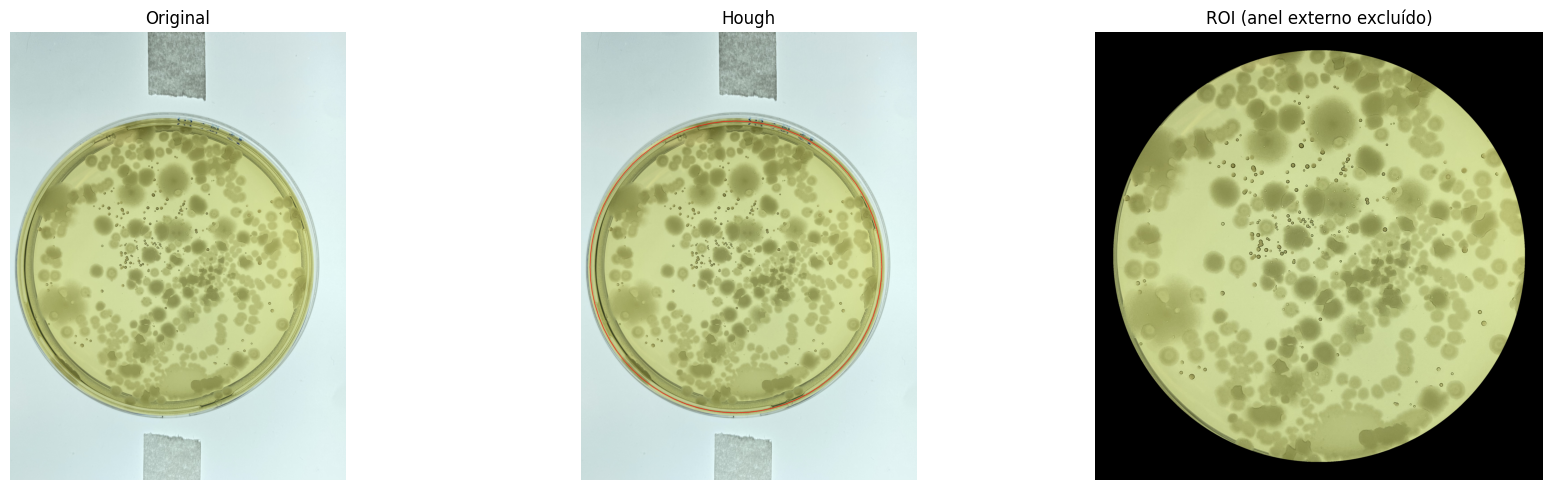

In [ ]:
# ── PASSO 1: ROI com Hough Circle ─────────────────────────────────────────
# Function 'detectar_placa' moved to setup cell -nH7B6_T2rD2

img_roi, mascara_roi, (cx, cy, r) = detectar_placa(img_orig)
debug = img_orig.copy(); cv2.circle(debug, (cx,cy), r, (255,0,0), 3)
mostrar([img_orig, debug, img_roi], ['Original', 'Hough', 'ROI (anel externo excluído)'])


## PASSO 1: Detecção da Região de Interesse (ROI) com Hough Circle

O primeiro passo do pipeline é identificar e isolar a placa de Petri na imagem. Para isso, aplicamos a **Transformada de Hough para Círculos** (`cv2.HoughCircles`).

*   A função `detectar_placa` (definida na seção de setup) recebe a imagem original e parâmetros para a detecção de círculos.
*   Após a detecção, é criada uma máscara para excluir a área externa da placa e, opcionalmente, uma pequena borda interna onde textos impressos podem interferir na contagem.
*   O resultado é a imagem recortada para a ROI e uma máscara binária da área válida.

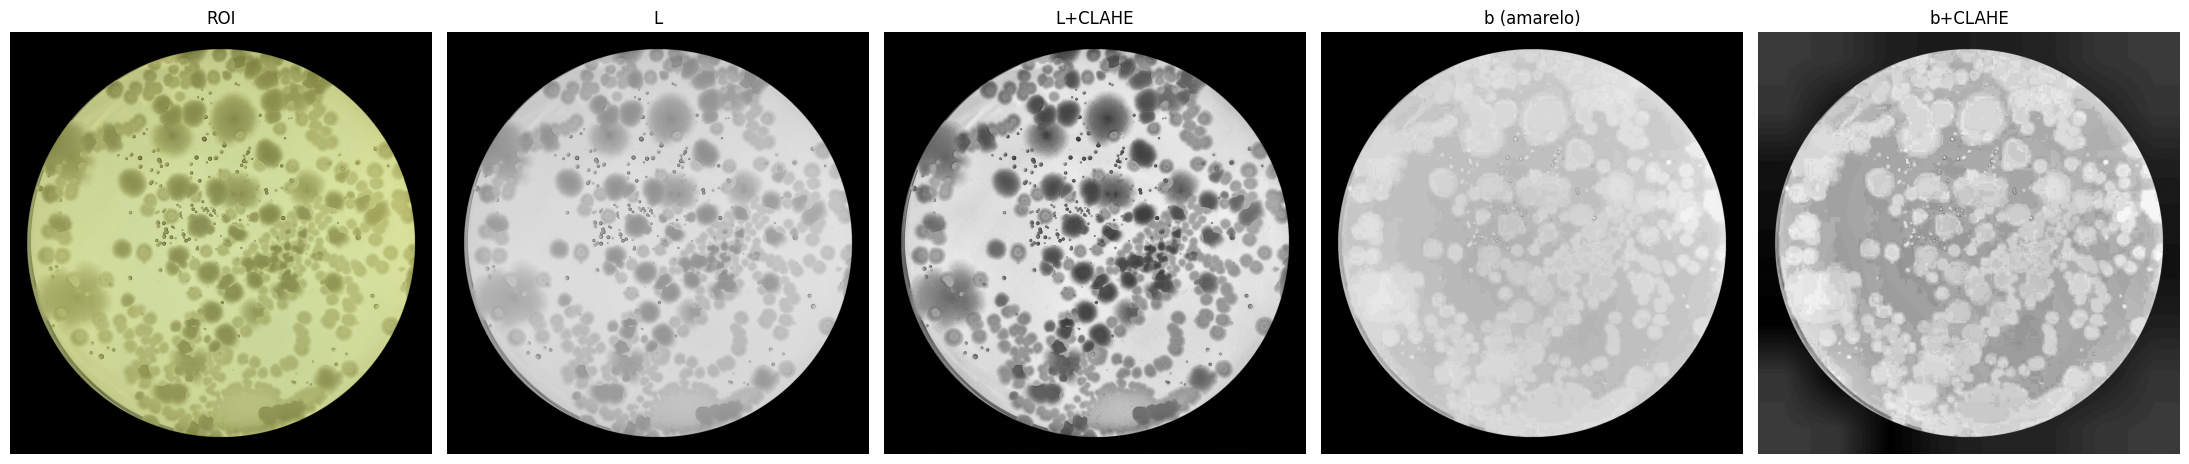

Escolha visualmente qual canal separa melhor colônia do agar.
Se b+CLAHE não ajudar, troque canal_escolhido para L_clahe.


In [ ]:
# ── PASSO 2: Espaço Lab — canais L e b ────────────────────────────────────
# Lab é perceptualmente uniforme: L=luminosidade, b=azul↔amarelo
# Colônias amarelas levemente diferentes do agar → canal b discrimina melhor que V
img_lab = cv2.cvtColor(img_roi, cv2.COLOR_RGB2LAB)
canal_L = img_lab[:,:,0]   # luminosidade (0–255 no OpenCV)
canal_b = img_lab[:,:,2]   # azul-amarelo  (0–255, neutro=128)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
L_clahe = clahe.apply(canal_L)
b_clahe = clahe.apply(canal_b)

mostrar([img_roi, canal_L, L_clahe, canal_b, b_clahe],
        ['ROI', 'L', 'L+CLAHE', 'b (amarelo)', 'b+CLAHE'], figsize=(22,5))
print('Escolha visualmente qual canal separa melhor colônia do agar.')
print('Se b+CLAHE não ajudar, troque canal_escolhido para L_clahe.')

# ⚠️ Mude para L_clahe se canal b não discriminar bem nas suas imagens
canal_escolhido = L_clahe

## PASSO 2: Conversão para Espaço Lab e CLAHE

Para melhorar a discriminação das colônias, convertemos a imagem da ROI para o espaço de cores **Lab**, que separa a luminosidade (L) dos canais de cor (a e b). O canal 'b' é particularmente útil para colônias amareladas.

*   **`img_lab = cv2.cvtColor(img_roi, cv2.COLOR_RGB2LAB)`**: Converte a imagem de RGB para Lab.
*   **`canal_L`** e **`canal_b`**: Extraem os canais de luminosidade e azul-amarelo, respectivamente.
*   **CLAHE (Contrast Limited Adaptive Histogram Equalization)**: É aplicado separadamente aos canais L e b (`L_clahe`, `b_clahe`) para realçar o contraste localmente, o que pode ajudar a destacar colônias em regiões com iluminação irregular.

A escolha do canal (`L_clahe` ou `b_clahe`) para as próximas etapas é feita visualmente, dependendo de qual oferece melhor separação entre colônias e agar.

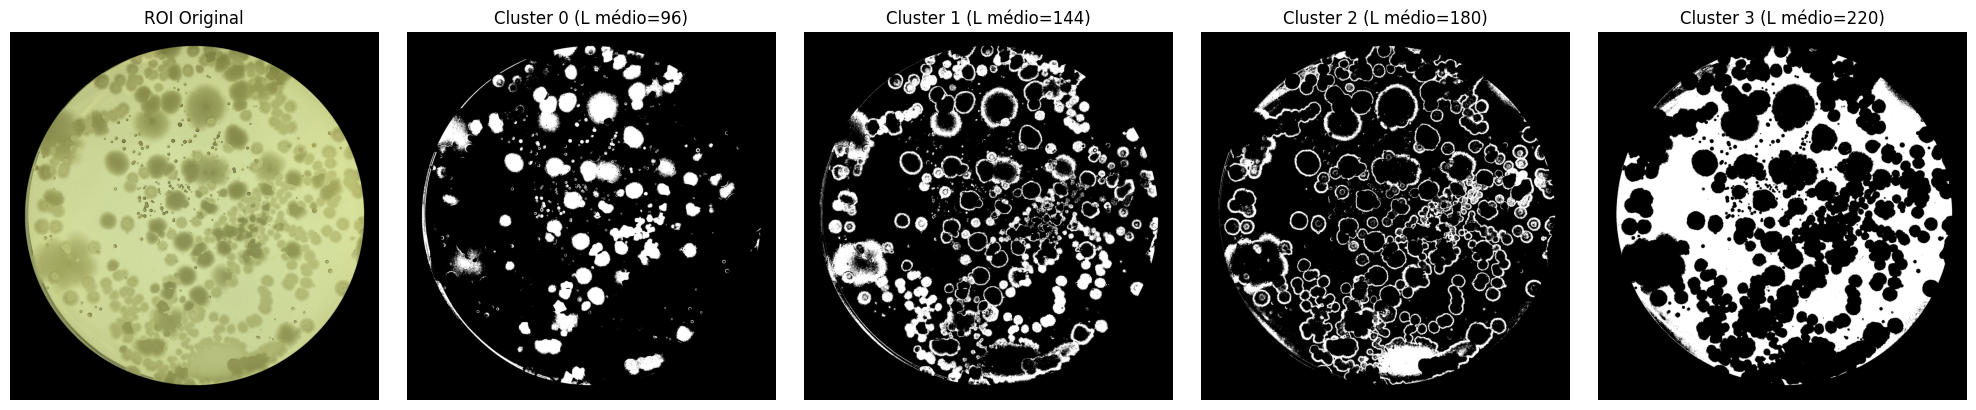

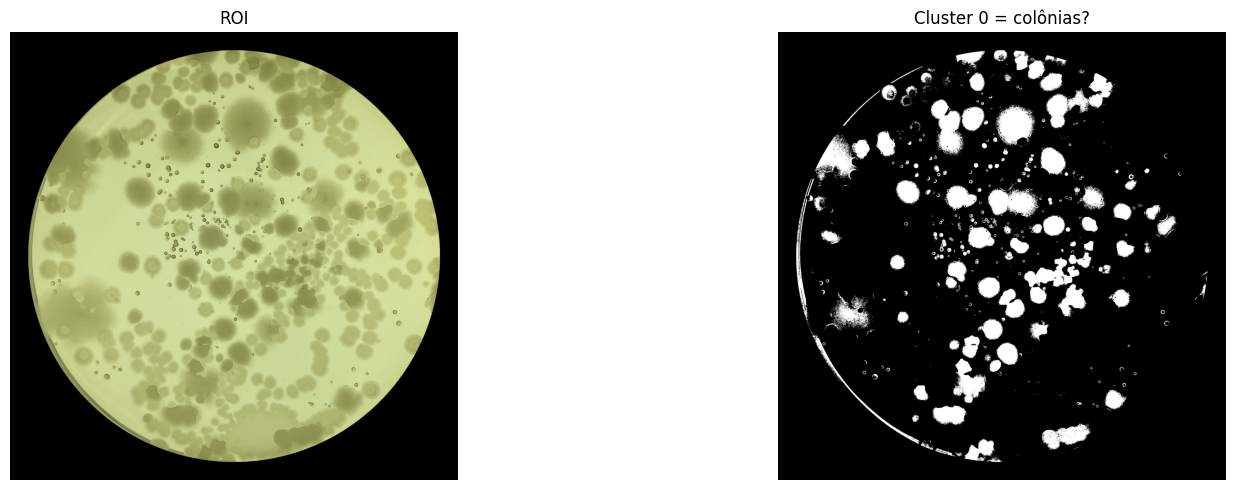

In [ ]:
# ── PASSO 3A: K-Means k=4 (apenas pixels da placa) ────────────────────────
# Features: [L_clahe, b_clahe] — 2D para separar luminosidade e cor ao mesmo tempo
# K-Means aplicado SOMENTE nos pixels dentro da máscara (exclui preto exterior)

K = 4  # ⚠️ 4 clusters: exterior_preto / agar / colônias / texto_alto_contraste

pixels_dentro = mascara_roi > 0  # boolean mask dos pixels válidos
features = np.stack([L_clahe, b_clahe], axis=-1).astype(np.float32)
X = features[pixels_dentro]  # shape: (N_pixels_validos, 2)

km = KMeans(n_clusters=K, n_init=5, random_state=42)
labels_flat = km.fit_predict(X)

# Reconstrói mapa de labels no tamanho da imagem
label_img = np.zeros(canal_L.shape, dtype=np.int32)
label_img[pixels_dentro] = labels_flat
label_img[~pixels_dentro] = -1  # exterior = -1

# Ordena clusters por L_clahe médio (0=mais escuro → K-1=mais claro)
centros_L = km.cluster_centers_[:, 0]
ordem = np.argsort(centros_L)  # do mais escuro ao mais claro
rank_img = np.full_like(label_img, -1)
for rank, orig in enumerate(ordem):
    rank_img[label_img == orig] = rank

# Visualiza cada cluster
fig, axes = plt.subplots(1, K+1, figsize=(20,4))
axes[0].imshow(img_roi); axes[0].set_title('ROI Original'); axes[0].axis('off')
for i in range(K):
    axes[i+1].imshow(rank_img == i, cmap='gray')
    axes[i+1].set_title(f'Cluster {i} (L médio={centros_L[ordem[i]]:.0f})')
    axes[i+1].axis('off')
plt.tight_layout(); plt.show()

# ⚠️ Inspecione visualmente e ajuste CLUSTER_COLONIA
# Geralmente as colônias ficam no cluster 2 (médio-claro) e texto no 3 (mais claro)
CLUSTER_COLONIA = 0
binaria_kmeans = np.where(rank_img == CLUSTER_COLONIA, 255, 0).astype(np.uint8)
mostrar([img_roi, binaria_kmeans], ['ROI', f'Cluster {CLUSTER_COLONIA} = colônias?'])

## PASSO 3A: Segmentação com K-Means

Nesta etapa, utilizamos o algoritmo de **K-Means** para agrupar os pixels da imagem em `K` clusters, com base em suas características de luminosidade e cor (canais L e b).

*   **`K = 4`**: Definimos 4 clusters, com o objetivo de separar: fundo preto externo, agar, colônias e, possivelmente, regiões de alto contraste como texto.
*   O K-Means é aplicado **somente nos pixels dentro da máscara da ROI**, para evitar que o fundo preto domine os clusters.
*   Os `features` para o K-Means são uma combinação dos canais `L_clahe` e `b_clahe`, permitindo que o algoritmo use tanto a informação de brilho quanto de cor.
*   Após a clusterização, os clusters são ordenados pela luminosidade média (`centros_L`). Isso ajuda a identificar qual cluster corresponde às colônias (geralmente um cluster de luminosidade média).
*   **`CLUSTER_COLONIA`**: Uma variável que deve ser ajustada visualmente para selecionar o cluster que melhor representa as colônias. A saída binária (`binaria_kmeans`) é criada a partir deste cluster.

blob_log detectou 2339 colônias | Real: 0 (placeholder)


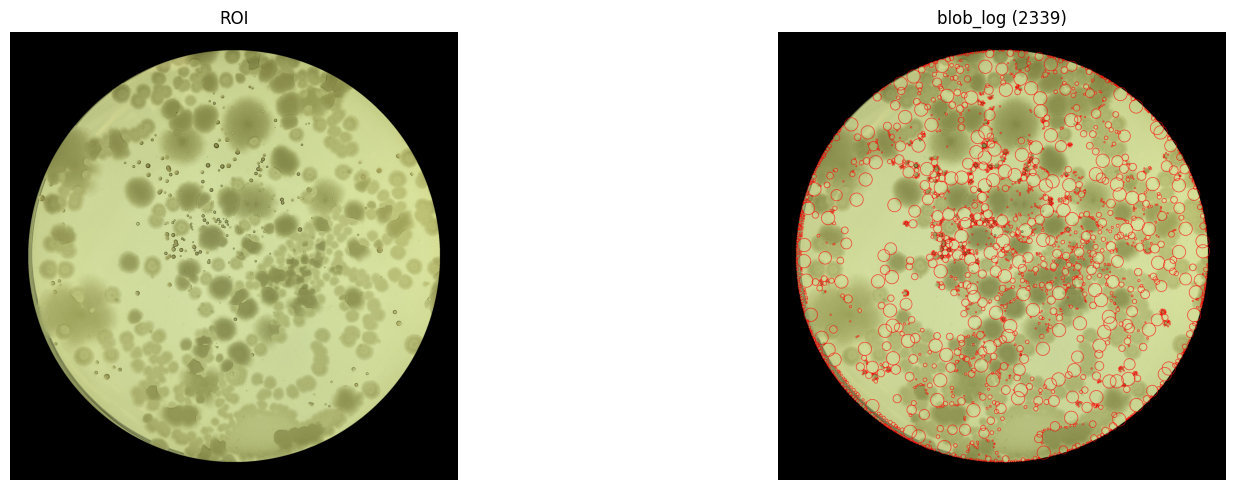

In [ ]:
# ── PASSO 3B: blob_log — alternativa sem binarização ──────────────────────
# Detecta manchas circulares diretamente no canal contínuo
# Não precisa de umbral; funciona com contraste baixo
# min_sigma / max_sigma em pixels ≈ raio_colonia / √2

img_norm = canal_escolhido.astype(np.float32) / 255.0

# ⚠️ Ajuste min_sigma e max_sigma conforme tamanho das colônias
# sigma ≈ raio / 1.41  →  colônias de raio 5–40px → sigma 3–28
blobs = feature.blob_log(
    img_norm,
    min_sigma=3,
    max_sigma=28,
    num_sigma=20,
    threshold=0.05,   # ⚠️ diminuir = mais sensível; aumentar = menos falsos positivos
    overlap=0.5
)

# Filtra blobs fora da máscara (exterior da placa)
blobs_validos = []
for y, x, s in blobs:
    yi, xi = int(y), int(x)
    if 0 <= yi < mascara_roi.shape[0] and 0 <= xi < mascara_roi.shape[1]:
        if mascara_roi[yi, xi] > 0:
            blobs_validos.append((y, x, s))

img_blobs = img_roi.copy()
for y, x, s in blobs_validos:
    cv2.circle(img_blobs, (int(x), int(y)), int(s * 1.41), (255,0,0), 2)

print(f'blob_log detectou {len(blobs_validos)} colônias | Real: {contagem_real} (placeholder)')
mostrar([img_roi, img_blobs], ['ROI', f'blob_log ({len(blobs_validos)})'])

## PASSO 3B: Detecção de Blobs com `blob_log` (Alternativa)

Como uma alternativa à binarização e K-Means, esta seção demonstra o uso da função `blob_log` da biblioteca `skimage` para detectar diretamente manchas circulares (blobs) na imagem, sem a necessidade de uma etapa de limiarização binária explícita. Este método é robusto para imagens com baixo contraste.

*   **`img_norm = canal_escolhido.astype(np.float32) / 255.0`**: Normaliza o canal escolhido (L ou b) para o intervalo [0, 1].
*   **`feature.blob_log`**: Implementa o detector de blobs baseado no Laplaciano de Gaussianas. Seus parâmetros `min_sigma` e `max_sigma` controlam o tamanho dos blobs a serem detectados (relacionados ao raio das colônias), e `threshold` controla a sensibilidade da detecção.
*   Os blobs detectados são filtrados para garantir que estejam dentro da área da placa (ROI).
*   Os blobs válidos são visualizados como círculos na imagem original da ROI.

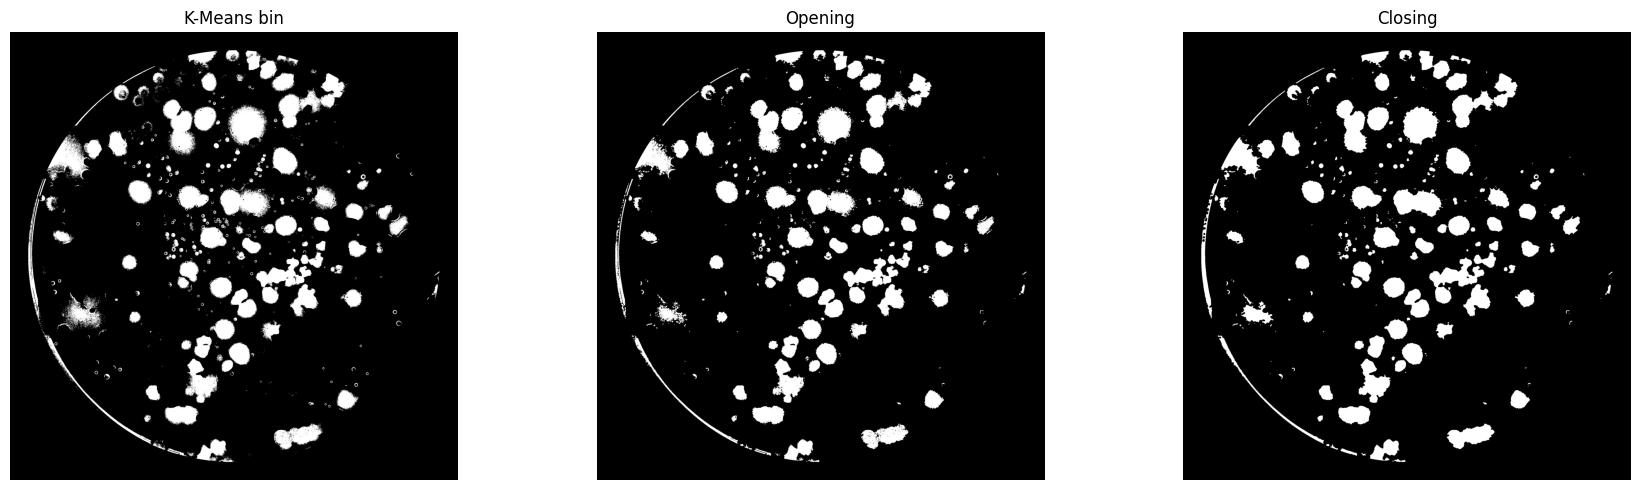

In [ ]:
# ── PASSO 4: Morfologia + Filtros de forma (K-Means path) ─────────────────
ks = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3,3))
km_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5,5))
opening = cv2.morphologyEx(binaria_kmeans, cv2.MORPH_OPEN,  ks, iterations=2)
closing = cv2.morphologyEx(opening,        cv2.MORPH_CLOSE, km_k, iterations=2)
binaria_limpa = closing

mostrar([binaria_kmeans, opening, closing], ['K-Means bin', 'Opening', 'Closing'])

## PASSO 4: Operações Morfológicas (Caminho K-Means)

Após a binarização obtida pelo K-Means, aplicamos operações morfológicas para refinar a segmentação, remover ruídos pequenos e suavizar os contornos das colônias.

*   **`opening` (Abertura)**: Realiza uma erosão seguida de uma dilatação. Ajuda a remover pequenos objetos (ruído) e a quebrar pontes finas entre objetos maiores.
*   **`closing` (Fechamento)**: Realiza uma dilatação seguida de uma erosão. Ajuda a preencher pequenos buracos dentro dos objetos e a conectar componentes próximos.
*   Os elementos estruturantes (`ks`, `km_k`) são definidos como elipses, adequados para formas aproximadamente circulares das colônias.

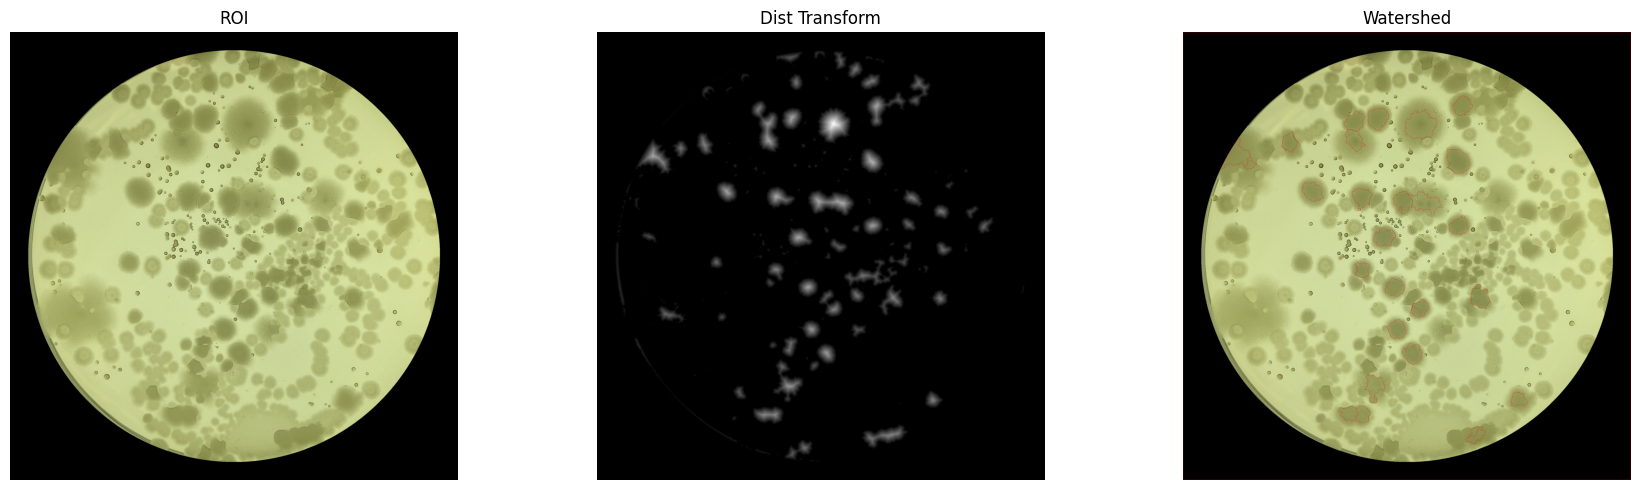

In [ ]:
# ── PASSO 5: Watershed ─────────────────────────────────────────────────────
# Function 'watershed' moved to setup cell -nH7B6_T2rD2

img_ws, dist = watershed(binaria_limpa, img_roi, dist_thresh=0.5)
mostrar([img_roi, dist, img_ws], ['ROI', 'Dist Transform', 'Watershed'])

## PASSO 5: Segmentação com Watershed

O algoritmo **Watershed** é utilizado para separar colônias que estão aglomeradas ou se tocando, o que é um desafio comum em imagens de placas de Petri. Ele trata a imagem como uma paisagem topográfica, onde os "vales" representam os centros dos objetos e as "montanhas" são as fronteiras.

*   **`dist = cv2.distanceTransform(binaria_limpa, cv2.DIST_L2, 5)`**: Calcula a transformada de distância na imagem binária limpa. Isso gera uma imagem onde cada pixel tem um valor que representa a distância até a borda mais próxima do objeto.
*   **`sure_bg` (Fundo Certeiro)**: Obtido por dilatação da imagem binária, representa a área de fundo.
*   **`sure_fg` (Objetos Certeiros)**: Obtido por um limiar na transformada de distância, representa o núcleo dos objetos (colônias).
*   **`unknown`**: A região entre `sure_bg` e `sure_fg`, onde as fronteiras dos objetos serão determinadas.
*   **`cv2.watershed`**: Aplica o algoritmo, usando marcadores (`markers`) para guiar a segmentação. O resultado (`img_ws`) mostra as colônias separadas por linhas de fronteira.

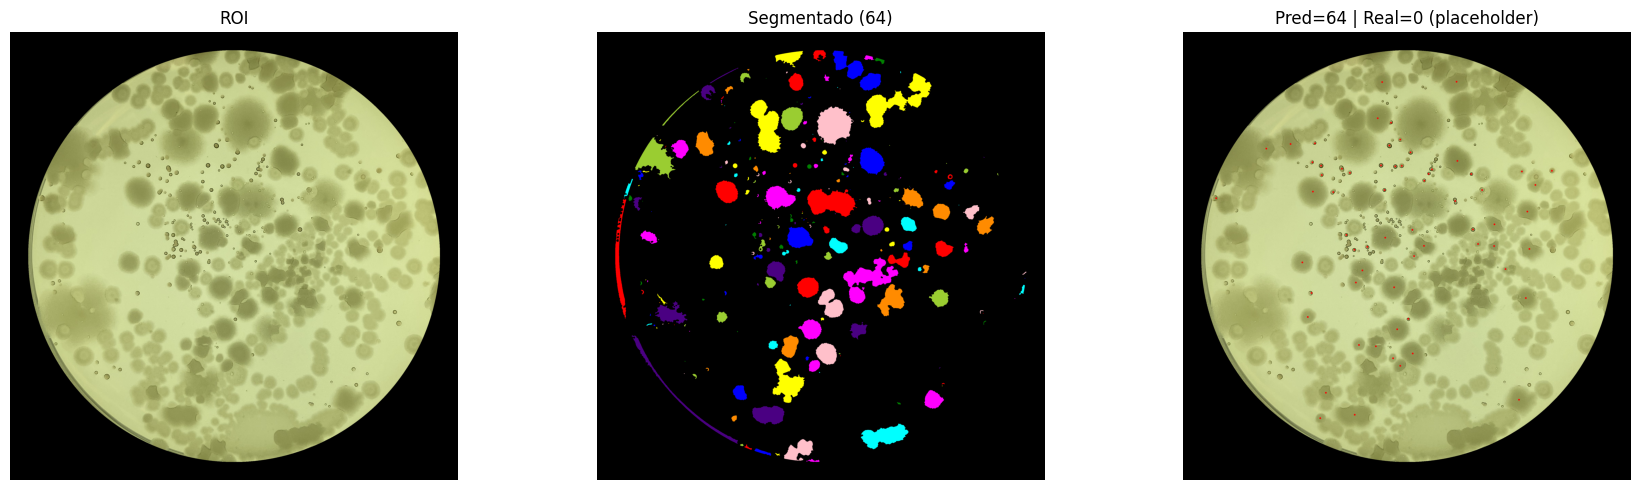

Real: 0 (placeholder) | Pred: 64 | Erro: 64


In [ ]:
# ── PASSO 6: Contagem com circularidade + solidez ─────────────────────────
# Circularidade = 4π×área / perímetro²  →  círculo=1.0, letra<0.4
# Solidez       = área / área_convex_hull  →  colônia≈0.9, letra≈0.6
AREA_MIN  = 200
AREA_MAX  = 30000
CIRC_MIN  = 0.55   # ⚠️ ajuste; aumentar = mais restritivo (elimina mais não-colônias)
SOLID_MIN = 0.75   # ⚠️ ajuste; solidez baixa = forma irregular = não é colônia

rotulada = measure.label(binaria_limpa)
regioes  = []
for reg in measure.regionprops(rotulada):
    if not (AREA_MIN <= reg.area <= AREA_MAX): continue
    circ  = (4 * np.pi * reg.area) / (reg.perimeter**2) if reg.perimeter > 0 else 0
    solid = reg.solidity
    if circ >= CIRC_MIN and solid >= SOLID_MIN:
        regioes.append(reg)

n_pred = len(regioes)

img_final = img_roi.copy()
for reg in regioes:
    cy_r, cx_r = int(reg.centroid[0]), int(reg.centroid[1])
    cv2.circle(img_final, (cx_r, cy_r), 5, (255,0,0), -1)

img_seg = color.label2rgb(rotulada, bg_label=0)
mostrar([img_roi, img_seg, img_final],
        ['ROI', f'Segmentado ({n_pred})', f'Pred={n_pred} | Real={contagem_real} (placeholder)'])
print(f'Real: {contagem_real} (placeholder) | Pred: {n_pred} | Erro: {abs(contagem_real-n_pred)}')


## PASSO 6: Contagem e Filtros de Forma

Nesta etapa final, identificamos e contamos as colônias segmentadas, aplicando filtros baseados em suas propriedades morfológicas para descartar ruídos ou objetos que não são colônias.

*   **`measure.label(binaria_limpa)`**: Rotula cada componente conectado na imagem binária, atribuindo um ID único a cada objeto potencial.
*   **`measure.regionprops(rotulada)`**: Extrai diversas propriedades para cada região rotulada, como área, perímetro, centroide, etc.
*   **Filtros Aplicados**: Para cada região, verificamos:
    *   **`AREA_MIN` e `AREA_MAX`**: Filtram objetos com áreas muito pequenas (ruído) ou muito grandes (agrupamentos não separados corretamente).
    *   **`CIRC_MIN` (Circularidade)**: Uma métrica que quantifica o quão circular é um objeto. Colônias tendem a ser mais circulares (valor próximo de 1.0), enquanto ruídos ou texto são menos. Ajustar este parâmetro pode eliminar objetos não circulares.
    *   **`SOLID_MIN` (Solidez)**: A razão entre a área do objeto e a área de sua convex hull (o menor polígono convexo que o contém). Colônias geralmente têm alta solidez (próximo de 1.0), enquanto formas irregulares como texto têm solidez menor.
*   A contagem final (`n_pred`) é o número de regiões que satisfazem todos esses critérios.

In [ ]:
# ── Pipeline completo + MAE ────────────────────────────────────────────────
def pipeline(img_rgb, k=4, cluster_colonia=2,
             area_min=200, area_max=30000,
             circ_min=0.55, solid_min=0.75,
             dist_thresh=0.5):
    # 1. ROI
    roi, mask, _ = detectar_placa(img_rgb)
    if roi.shape[0] == 0 or roi.shape[1] == 0: return 0

    # 2. Lab + CLAHE
    lab   = cv2.cvtColor(roi, cv2.COLOR_RGB2LAB)
    cl    = cv2.createCLAHE(2.0, (8,8))
    L_cl  = cl.apply(lab[:,:,0])
    b_cl  = cl.apply(lab[:,:,2])

    # 3. K-Means nos pixels válidos
    inside = mask > 0
    X = np.stack([L_cl, b_cl], axis=-1).astype(np.float32)[inside]
    if len(X) < k: return 0
    km_model = KMeans(n_clusters=k, n_init=5, random_state=42)
    labels   = km_model.fit_predict(X)
    label_img = np.full(L_cl.shape, -1, dtype=np.int32)
    label_img[inside] = labels
    ordem = np.argsort(km_model.cluster_centers_[:, 0])
    rank  = np.full_like(label_img, -1)
    for r, orig in enumerate(ordem): rank[label_img==orig] = r
    binaria = np.where(rank == cluster_colonia, 255, 0).astype(np.uint8)

    # 4. Morfologia
    ks = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(3,3))
    km_k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(5,5))
    op = cv2.morphologyEx(binaria, cv2.MORPH_OPEN,  ks, iterations=2)
    cl2 = cv2.morphologyEx(op,     cv2.MORPH_CLOSE, km_k, iterations=2)

    # 5. Watershed
    ws_img, _ = watershed(cl2, roi, dist_thresh)

    # 6. Contagem
    count = 0
    for reg in measure.regionprops(measure.label(cl2)):
        if not (area_min <= reg.area <= area_max): continue
        circ  = (4*np.pi*reg.area)/(reg.perimeter**2) if reg.perimeter>0 else 0
        if circ >= circ_min and reg.solidity >= solid_min: count += 1
    return count

# Changed to process the single HEIC image
pred = pipeline(img_orig)
real = contagem_real # This is 0 for the HEIC image
erro = abs(pred - real)

print(f"Processando a imagem HEIC: Predição = {pred}, Real (placeholder) = {real}, Erro = {erro}")

# The following code for MAE/sMAE calculation for a dataset is commented out
# as it's not applicable for a single image.
# resultados = []
# for a in amostras:
#     pred = pipeline(a['imagem'])
#     real = a['contagem_real']
#     erro = abs(pred - real)
#     resultados.append({'nome': a['nome'][:20], 'real': real, 'pred': pred,
#                        'erro': erro, 'smae': round(erro/real,3) if real>0 else 0})

# print(f"{'Nome':<22}{'Real':>6}{'Pred':>6}{'Erro':>6}{'sMAE':>7}")
# print('-'*45)
# for r in resultados:
#     print(f"{r['nome']:<22}{r['real']:>6}{r['pred']:>6}{r['erro']:>6}{r['smae']:>7}")
# mae  = np.mean([r['erro']  for r in resultados])
# smae = np.mean([r['smae'] for r in resultados])
# print(f'\n📊 MAE: {mae:.2f} | sMAE: {smae:.3f}')

Processando a imagem HEIC: Predição = 3, Real (placeholder) = 0, Erro = 3


## 🧪 Pipeline Completo Consolidado

Esta seção apresenta a função `pipeline` que encapsula todos os passos de processamento de imagem descritos anteriormente em uma única função. Ela permite passar parâmetros para cada etapa, facilitando a experimentação e otimização.

**Parâmetros Ajustáveis:**

*   `k`, `cluster_colonia`: Para a etapa de K-Means.
*   `area_min`, `area_max`, `circ_min`, `solid_min`: Para os filtros de forma na contagem.
*   `dist_thresh`: Para o algoritmo Watershed.

Esta função é projetada para ser aplicada a um conjunto de imagens para avaliar a performance do modelo, calculando métricas de erro como o Erro Absoluto Médio (MAE) quando um `contagem_real` (número de colônias real) está disponível. No entanto, para o caso de uma única imagem HEIC, ela processa a imagem e retorna a predição.

In [ ]:
# ── Gráfico Real vs Predito ────────────────────────────────────────────────
# This plot is designed for multiple images and a dataset.
# It is commented out as we are now processing a single HEIC image.

# x = np.arange(len(resultados))
# fig, ax = plt.subplots(figsize=(14,5))
# ax.bar(x-0.2, [r['real'] for r in resultados], 0.4, label='Real',    color='steelblue')
# ax.bar(x+0.2, [r['pred'] for r in resultados], 0.4, label='Predito', color='tomato')
# ax.set_xticks(x); ax.set_xticklabels([r['nome'] for r in resultados], rotation=30, ha='right')
# ax.set_title(f'Real vs Predito — MAE={mae:.2f} | sMAE={smae:.3f}')
# ax.legend(); plt.tight_layout(); plt.show()

## Guia de Ajuste

| Parâmetro | Onde | O que faz |
|---|---|---|
| `margem` / `r_inner` em `detectar_placa` | ROI | `0.92` exclui 8% do anel externo (texto); aumentar se texto ainda aparecer |
| `canal_escolhido` | PASSO 2 | Troque entre `L_clahe` e `b_clahe`; use o que separa melhor visualmente |
| `K` | K-Means | 4 para a maioria; aumentar para 5 se ainda misturar clusters |
| `CLUSTER_COLONIA` | K-Means | Inspecione os clusters visualmente e ajuste (0=escuro … K-1=claro) |
| `threshold` em `blob_log` | PASSO 3B | Diminuir = mais sensível; aumentar = menos falsos positivos |
| `min_sigma`/`max_sigma` | blob_log | ≈ raio_min/1.41 e raio_max/1.41 em pixels |
| `dist_thresh` | Watershed | 0.5 conservador; diminuir para separar mais colônias sobrepostas |
| `CIRC_MIN` | Contagem | 0.55 recomendado; aumentar para eliminar mais não-colônias |
| `SOLID_MIN` | Contagem | 0.75 recomendado; formas irregulares (texto) têm solidez < 0.6 |

**Se K-Means ainda misturar colônias com agar:** tente `K=5` e combine `CLUSTER_COLONIA=[2,3]` — some os dois clusters e aplique morfologia.

**Se blob_log detectar muito ruído:** aumente `threshold` de 0.05 para 0.10–0.15.

## 📚 Recursos

Esta seção é dedicada a listar quaisquer recursos adicionais, referências ou informações relevantes para o notebook. No momento, está vazia, mas pode ser expandida conforme necessário.